In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
df =pd.read_excel(r"C:\Users\shaheer\Downloads\ABC Company.xlsx")
df=df.dropna()
df.head(10)

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
6,Jordan Mickey,Boston Celtics,55,PF,21,2023-08-06 00:00:00,235,LSU,1170960.0
7,Kelly Olynyk,Boston Celtics,41,C,25,7-0,238,Gonzaga,2165160.0
8,Terry Rozier,Boston Celtics,12,PG,22,2023-02-06 00:00:00,190,Louisville,1824360.0
9,Marcus Smart,Boston Celtics,36,PG,22,2023-04-06 00:00:00,220,Oklahoma State,3431040.0
10,Jared Sullinger,Boston Celtics,7,C,24,2023-09-06 00:00:00,260,Ohio State,2569260.0
11,Isaiah Thomas,Boston Celtics,4,PG,27,2023-09-05 00:00:00,185,Washington,6912869.0
12,Evan Turner,Boston Celtics,11,SG,27,2023-07-06 00:00:00,220,Ohio State,3425510.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      365 non-null    object 
 1   Team      365 non-null    object 
 2   Number    365 non-null    int64  
 3   Position  365 non-null    object 
 4   Age       365 non-null    int64  
 5   Height    365 non-null    object 
 6   Weight    365 non-null    int64  
 7   College   365 non-null    object 
 8   Salary    365 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 28.5+ KB


● Correct the data in the "height" column by replacing it with random
numbers between 150 and 180. Ensure data consistency and integrity
before proceeding with analysis.

In [5]:
df['Height']=np.random.randint(150,181,size=len(df))
df
#

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,150,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,178,235,Marquette,6796117.0
3,R.J. Hunter,Boston Celtics,28,SG,22,160,185,Georgia State,1148640.0
6,Jordan Mickey,Boston Celtics,55,PF,21,178,235,LSU,1170960.0
7,Kelly Olynyk,Boston Celtics,41,C,25,165,238,Gonzaga,2165160.0
...,...,...,...,...,...,...,...,...,...
451,Chris Johnson,Utah Jazz,23,SF,26,165,206,Dayton,981348.0
452,Trey Lyles,Utah Jazz,41,PF,20,169,234,Kentucky,2239800.0
453,Shelvin Mack,Utah Jazz,8,PG,26,178,203,Butler,2433333.0
456,Jeff Withey,Utah Jazz,24,C,26,151,231,Kansas,947276.0


In [42]:
team_height = df.groupby("Team")["Height"].mean()
print(team_height.idxmax())


Phoenix Suns


### Analysis Tasks:

● Determine the distribution of employees across each team and calculate
the percentage split relative to the total number of employees. 

In [5]:
Team_num=df['Team'].value_counts().head(10)
Team_num

Team
New Orleans Pelicans      16
Portland Trail Blazers    15
Detroit Pistons           15
Milwaukee Bucks           14
Philadelphia 76ers        14
Oklahoma City Thunder     14
Los Angeles Clippers      14
Washington Wizards        13
Charlotte Hornets         13
Phoenix Suns              13
Name: count, dtype: int64

In [6]:
Team_pec=(Team_num/len(df))*365
Team_pec

Team
New Orleans Pelicans      16.0
Portland Trail Blazers    15.0
Detroit Pistons           15.0
Milwaukee Bucks           14.0
Philadelphia 76ers        14.0
Oklahoma City Thunder     14.0
Los Angeles Clippers      14.0
Washington Wizards        13.0
Charlotte Hornets         13.0
Phoenix Suns              13.0
Name: count, dtype: float64

In [7]:
summary = pd.DataFrame({
    "Employee Count": Team_num,
    "Percentage (%)": Team_pec.round(2)
})
summary


,Employee Count,Percentage (%)
Team,,
New Orleans Pelicans,16,16.0
Portland Trail Blazers,15,15.0
Detroit Pistons,15,15.0
Milwaukee Bucks,14,14.0
Philadelphia 76ers,14,14.0
Oklahoma City Thunder,14,14.0
Los Angeles Clippers,14,14.0
Washington Wizards,13,13.0
Charlotte Hornets,13,13.0


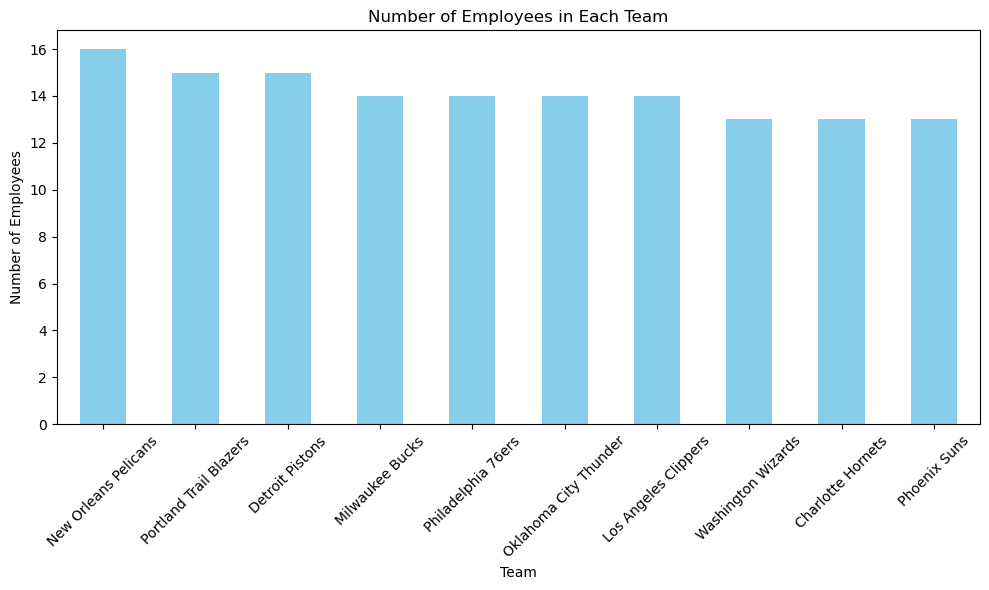

In [44]:
plt.figure(figsize=(10,6))
Team_num.plot(kind='bar', color='skyblue')
plt.title("Number of Employees in Each Team")
plt.xlabel("Team")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ANS Largest team :New Orleans Pelicans

● Segregate employees based on their positions within the company.


In [8]:
position_count = df["Position"].value_counts()
print(position_count)

Position
SG    87
PF    81
PG    76
SF    71
C     50
Name: count, dtype: int64


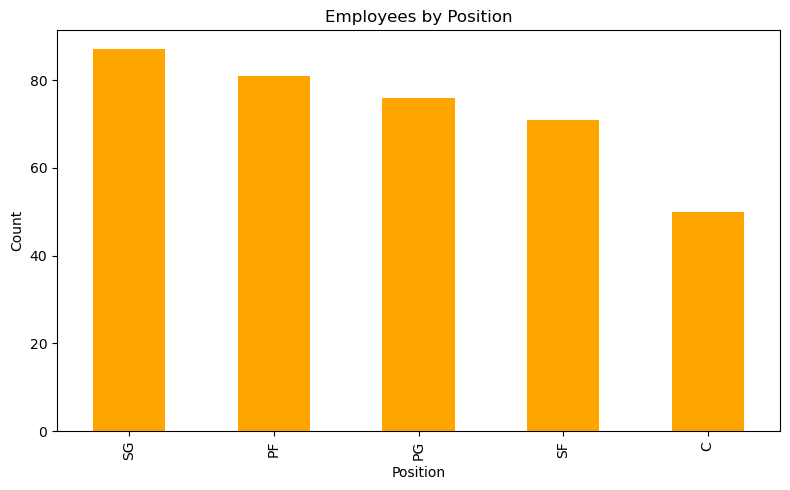

In [9]:
plt.figure(figsize=(8,5))
position_count.plot(kind="bar", color="orange")

plt.title("Employees by Position")
plt.xlabel("Position")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

 ### ANS:Most common position is SG

● Identify the predominant age group among employees.

In [10]:
df.columns

Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary'],
      dtype='object')

In [22]:
c=df["Age"].max()
d=df["Age"].min()
print(c)
print(d)

40
19


In [28]:
bins=[20,25,30,35,40]
labels=["20-25","26-30","31-35","36,40",]
df["Age group"]=pd.cut(df["Age"],bins=bins,labels=labels)


In [29]:
age_group=df["Age group"].value_counts()
age_group

Age group
20-25    153
26-30    131
31-35     48
36,40     16
Name: count, dtype: int64

In [32]:
print("Most common age group:")
print(age_group.idxmax())

Most common age group:
20-25


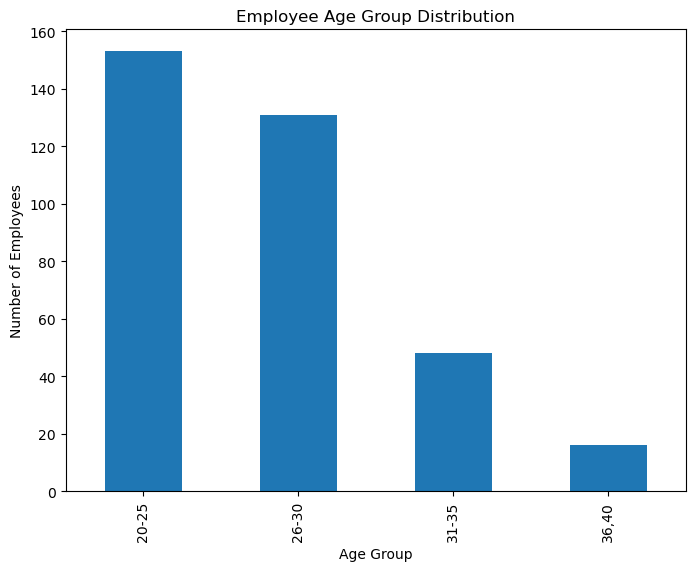

In [38]:
plt.figure(figsize=(8,6))
age_group.plot(kind="bar")
plt.title("Employee Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.show()

### ANS:Predominant age group = 20-25

● Discover which team and position have the highest salary expenditure.

In [41]:
df.columns

Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary', 'Age_group', 'Age group'],
      dtype='object')

In [24]:
teamu=df.groupby("Team")["Salary"].sum()
print("Salary Expenditure by Team:")
print(teamu)
print("Team with Highest Salary Expenditure:")
print(teamu.idxmax())


Salary Expenditure by Team:
Team
Atlanta Hawks             56383300.0
Boston Celtics            41541068.0
Brooklyn Nets             47503125.0
Charlotte Hornets         51715614.0
Chicago Bulls             73265800.0
Cleveland Cavaliers       74068189.0
Dallas Mavericks          57140305.0
Denver Nuggets            38167971.0
Detroit Pistons           67168263.0
Golden State Warriors     80535517.0
Houston Rockets           48445456.0
Indiana Pacers            48057601.0
Los Angeles Clippers      93906914.0
Los Angeles Lakers        39245338.0
Memphis Grizzlies         56862880.0
Miami Heat                65838121.0
Milwaukee Bucks           66794557.0
Minnesota Timberwolves    21310196.0
New Orleans Pelicans      68200408.0
New York Knicks           57977202.0
Oklahoma City Thunder     81515298.0
Orlando Magic             37887288.0
Philadelphia 76ers        30992894.0
Phoenix Suns              44945135.0
Portland Trail Blazers    48301818.0
Sacramento Kings          62786874.0
San A

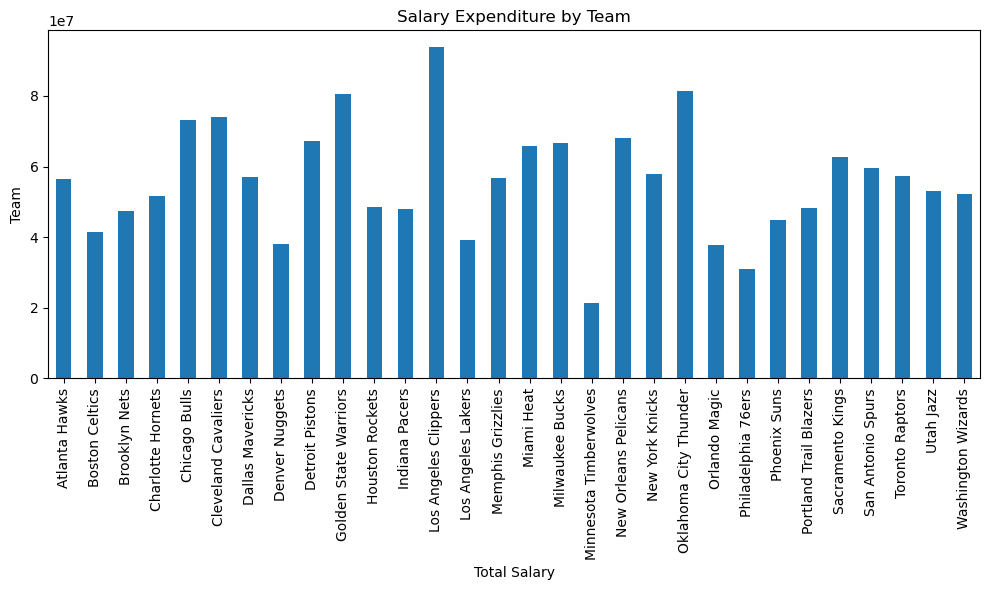

In [58]:
plt.figure(figsize=(10,6))

teamu.plot(kind="bar")

plt.title("Salary Expenditure by Team")
plt.xlabel("Total Salary")
plt.ylabel("Team")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### ANS:Highest salary expenditure team=Los Angeles Clippers

In [53]:
posu=df.groupby("Position")["Salary"].sum()
print("Salary Expenditure by Position:")
print(posu)
print("Position with Highest Salary Expenditure:")
print(posu.idxmax())

Salary Expenditure by Position:
Position
C     283376751.0
PF    361259021.0
PG    373621258.0
SF    326309441.0
SG    338174035.0
Name: Salary, dtype: float64
Position with Highest Salary Expenditure:
PG


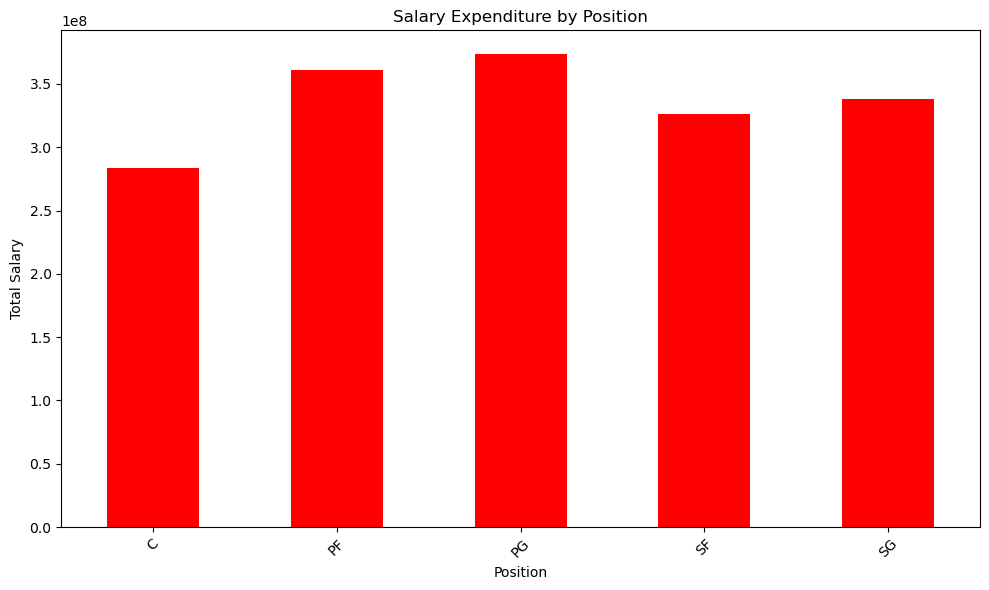

In [51]:
plt.figure(figsize=(10,6))

posu.plot(kind="bar", color="red")

plt.title("Salary Expenditure by Position")
plt.xlabel("Position")
plt.ylabel("Total Salary")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ANS:Highest salary expenditure position=PG

● Investigate if there's any correlation between age and salary, and
represent it visually.

In [59]:
df.columns

Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary', 'Age_group', 'Age group'],
      dtype='object')

In [71]:
salu=df[["Age","Salary"]].reset_index()
salu

,index,Age,Salary
0,0,25,7730337.0
1,1,25,6796117.0
2,3,22,1148640.0
3,6,21,1170960.0
4,7,25,2165160.0
...,...,...,...
360,451,26,981348.0
361,452,20,2239800.0
362,453,26,2433333.0
363,456,26,947276.0


In [61]:
cor= df["Age"].corr(df["Salary"])
print("Correlation between Age and Salary:")
print(round(cor, 3))

Correlation between Age and Salary:
0.16


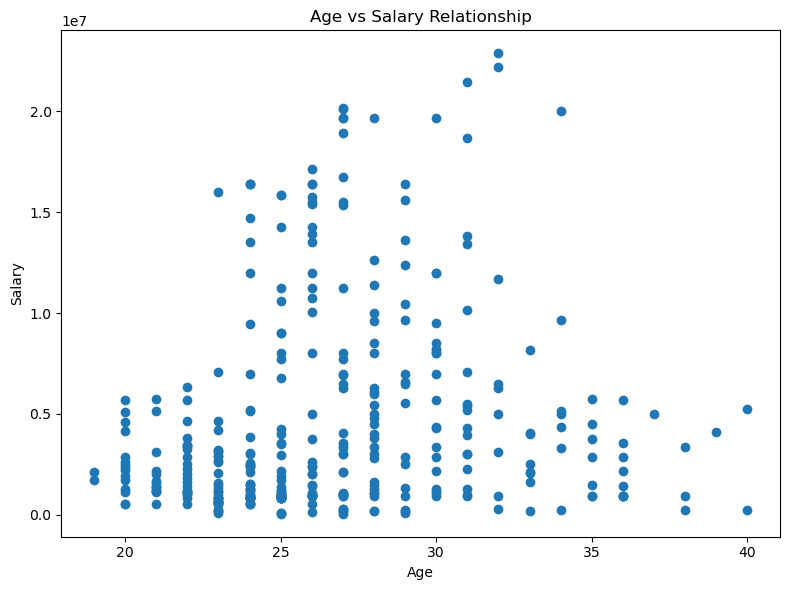

In [67]:
plt.figure(figsize=(8,6))

plt.scatter(df["Age"], df["Salary"])

plt.title("Age vs Salary Relationship")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.tight_layout()
plt.show()

### ANS:Correlation between Age and Salary =0.16